In [137]:
from astropy.table import Table
from astropy import units as u
from astropy.constants import c
import astropy.cosmology.units as cu

import matplotlib as mpl
import matplotlib.pyplot as plt

from scipy.optimize import minimize

import numpy as np

import numdifftools as ndt

In [12]:
loa_rotvel = Table.read('/pscratch/sd/d/dbustos/rot_curves/loa_rotvel.fits')
loa_rotvel[:5]

TARGETID,TARGET_RA,TARGET_DEC,Z,ZERR,SPECTYPE,DELTACHI2,ZWARN,PVTYPE,SGA_ID,PHOTSYS,DIST,DIST_R26,Selection,bad_fiber,ZERR_MOD,Velocity,V_err,Z_center,c_or_s,bad_map
int64,float64,float64,float64,float64,bytes6,float64,int64,bytes3,int64,bytes1,float64,float64,int64,int64,float64,float64,float64,float64,int64,int64
2350675715424256,239.8472,31.7866,0.1492904161251356,1.9422911736100356e-05,GALAXY,5071.658419655636,0,TFT,483369,S,0.00018163397694836428,0.04183588292464746,2,0,3.312680244156565e-05,93.48259787088467,16.871398281910924,3.92031082335997e-05,0,0
2389103635070977,61.51249486530825,-17.766542165450435,0.2898542763769689,1.3051647863939431e-05,GALAXY,585.0907674431801,0,TFT,526821,S,0.015034501051441454,0.40000000781105455,2,0,3.282385438171887e-05,85676.49697232743,16.492244492570364,4.3203103383505966e-05,0,0
2389161461940225,53.110693190838745,-15.204162701018703,1.41029052508368,0.00015282405234457233,GALAXY,2.055874802172184,4,TFT,431568,S,0.020469853344286103,0.4000000051000554,2,0,0.00016285736718600513,298349.9880839603,53.17659935570105,4.219147414512987e-05,1,1
2389161461940226,53.133949122267566,-15.238404516460593,1.490823662797069,8.773021438224206e-05,GALAXY,17.411476522684097,0,TFT,431568,S,0.020469853344283147,0.4000000050999976,2,0,0.00010525736360510445,318879.6974465264,35.84384591975731,4.219147414512987e-05,1,1
2389220349968384,67.92758592005009,-12.682644974455277,1.632425063296397,0.00018014046308523026,GALAXY,6.947847135365009,4,TFT,175172,S,0.007399622287542027,0.399999983148231,2,0,0.0001903381932319499,463859.8983985996,57.57010172761073,2.5458158785123104e-05,0,0


In [13]:
SGA = Table.read('/global/cfs/cdirs/cosmo/data/sga/2020/SGA-2020.fits', 'ELLIPSE')
SGA[:5]

SGA_ID,SGA_GALAXY,GALAXY,PGC,RA_LEDA,DEC_LEDA,MORPHTYPE,PA_LEDA,D25_LEDA,BA_LEDA,Z_LEDA,SB_D25_LEDA,MAG_LEDA,BYHAND,REF,GROUP_ID,GROUP_NAME,GROUP_MULT,GROUP_PRIMARY,GROUP_RA,GROUP_DEC,GROUP_DIAMETER,BRICKNAME,RA,DEC,D26,D26_REF,PA,BA,RA_MOMENT,DEC_MOMENT,SMA_MOMENT,G_SMA50,R_SMA50,Z_SMA50,SMA_SB22,SMA_SB22.5,SMA_SB23,SMA_SB23.5,SMA_SB24,SMA_SB24.5,SMA_SB25,SMA_SB25.5,SMA_SB26,G_MAG_SB22,R_MAG_SB22,Z_MAG_SB22,G_MAG_SB22.5,R_MAG_SB22.5,Z_MAG_SB22.5,G_MAG_SB23,R_MAG_SB23,Z_MAG_SB23,G_MAG_SB23.5,R_MAG_SB23.5,Z_MAG_SB23.5,G_MAG_SB24,R_MAG_SB24,Z_MAG_SB24,G_MAG_SB24.5,R_MAG_SB24.5,Z_MAG_SB24.5,G_MAG_SB25,R_MAG_SB25,Z_MAG_SB25,G_MAG_SB25.5,R_MAG_SB25.5,Z_MAG_SB25.5,G_MAG_SB26,R_MAG_SB26,Z_MAG_SB26,SMA_SB22_ERR,SMA_SB22.5_ERR,SMA_SB23_ERR,SMA_SB23.5_ERR,SMA_SB24_ERR,SMA_SB24.5_ERR,SMA_SB25_ERR,SMA_SB25.5_ERR,SMA_SB26_ERR,G_MAG_SB22_ERR,R_MAG_SB22_ERR,Z_MAG_SB22_ERR,G_MAG_SB22.5_ERR,R_MAG_SB22.5_ERR,Z_MAG_SB22.5_ERR,G_MAG_SB23_ERR,R_MAG_SB23_ERR,Z_MAG_SB23_ERR,G_MAG_SB23.5_ERR,R_MAG_SB23.5_ERR,Z_MAG_SB23.5_ERR,G_MAG_SB24_ERR,R_MAG_SB24_ERR,Z_MAG_SB24_ERR,G_MAG_SB24.5_ERR,R_MAG_SB24.5_ERR,Z_MAG_SB24.5_ERR,G_MAG_SB25_ERR,R_MAG_SB25_ERR,Z_MAG_SB25_ERR,G_MAG_SB25.5_ERR,R_MAG_SB25.5_ERR,Z_MAG_SB25.5_ERR,G_MAG_SB26_ERR,R_MAG_SB26_ERR,Z_MAG_SB26_ERR,G_COG_PARAMS_MTOT,G_COG_PARAMS_M0,G_COG_PARAMS_ALPHA1,G_COG_PARAMS_ALPHA2,G_COG_PARAMS_CHI2,R_COG_PARAMS_MTOT,R_COG_PARAMS_M0,R_COG_PARAMS_ALPHA1,R_COG_PARAMS_ALPHA2,R_COG_PARAMS_CHI2,Z_COG_PARAMS_MTOT,Z_COG_PARAMS_M0,Z_COG_PARAMS_ALPHA1,Z_COG_PARAMS_ALPHA2,Z_COG_PARAMS_CHI2,ELLIPSEBIT
int64,bytes16,bytes29,int64,float64,float64,bytes21,float32,float32,float32,float32,float32,float32,bool,bytes13,int64,bytes35,int16,bool,float64,float64,float32,bytes8,float64,float64,float32,bytes4,float32,float32,float64,float64,float32,float32,float32,float32,float32,float32,float32,float32,float32,float32,float32,float32,float32,float32,float32,float32,float32,float32,float32,float32,float32,float32,float32,float32,float32,float32,float32,float32,float32,float32,float32,float32,float32,float32,float32,float32,float32,float32,float32,float32,float32,float32,float32,float32,float32,float32,float32,float32,float32,float32,float32,float32,float32,float32,float32,float32,float32,float32,float32,float32,float32,float32,float32,float32,float32,float32,float32,float32,float32,float32,float32,float32,float32,float32,float32,float32,float32,float32,float32,float32,float32,float32,float32,float32,float32,float32,float32,float32,float32,float32,float32,int32
2,SGA-2020 2,PGC1283207,1283207,228.3770865,5.4232017,S?,152.2,0.36307806,0.724436,0.03463229,23.40448,16.976,False,LEDA-20181114,0,PGC1283207,1,True,228.3770865,5.4232017,0.36307806,2283p055,228.3770803831908,5.423191398593787,0.49470574,SB26,158.20142,0.545691,228.37700918822188,5.4232652570544015,10.897086,3.3509698,3.1147978,3.240862,5.902337,6.9126143,7.941369,8.997992,10.073601,11.199986,12.391357,13.561038,14.841172,16.966799,16.108246,15.486356,16.879545,16.024958,15.400715,16.818878,15.967034,15.341793,16.776297,15.925804,15.300776,16.746685,15.897334,15.272053,16.725166,15.876816,15.2521105,16.708357,15.862035,15.237181,16.696539,15.851936,15.226998,16.689613,15.844313,15.21976,0.013392451,0.02354,0.021872982,0.01736985,0.024445537,0.039866067,0.05026544,0.08455789,0.122911856,0.005682776,0.0054258136,0.0049038026,0.005588406,0.005323561,0.0047632363,0.00543534,0.005177031,0.0046343105,0.0053025587,0.005040888,0.0045181247,0.005206092,0.0049438984,0.0044374703,0.0051483097,0.0048758644,0.0043834248,0.0051032505,0.0048264163,0.004344248,0.0050705094,0.004792021,0.004319857,0.005054293,0.004765629,0.0043044444,16.65942,0.34037337,0.2978292,3.0239506,0.07928849,15.820566,0.2640441,0.34559453,3.3033552,0.003811298,15.195567,0.29826432,0.3001073,3.2333765,0.011723555,0
3,SGA-2020 3,PGC1310416,1310416,202.54443750000002,6.9345944,Sc,159.26,0.4017908,0.7816278,0.073888786,23.498482,16.85,False,LEDA-20181114,1,PGC1310416,1,True,202.54443750000002,6.9345944,0.4017908,

In [14]:
SGA_dict = {}
for i in range(len(SGA)):
    SGA_dict[SGA['SGA_ID'][i]] = i

## get distance from center to fiber in kpc/h

In [138]:
#Reduced Hubble Constant (km/s/Mpc)
H0 = 100 * u.km / u.s / u.Mpc

#c in km/s
c = c.to('km/s')

In [139]:
loa_rotvel['r_kpc']= np.nan
loa_rotvel['r26_kpc'] = np.nan

for i in np.unique(loa_rotvel['SGA_ID']):

    targ_id = loa_rotvel['SGA_ID'] == i

    sga_id = SGA_dict[i]

    # distance from us to center of galaxy
    d_center = (SGA['Z_LEDA'][sga_id] * c)/H0

    # convert R26 dist from arcmin to radians
    theta = np.radians((loa_rotvel['DIST_R26'][targ_id])/60)

    # real distance from center of galaxy to fiber in units kpc/h
    r_fiber = d_center * np.tan(theta) * 1000

    loa_rotvel['r_kpc'][targ_id]=abs(r_fiber)

    # # get r/R26 dist
    theta_r26 = np.radians((SGA['D26'][sga_id]/60))/2
    
    dist_r26 = d_center * np.tan(theta_r26) * 1000

    # c1= dist_r26 * np.tan(theta_r26-theta)
    
    r26_kpc = r_fiber/dist_r26

    loa_rotvel['r26_kpc'][targ_id] = abs(r26_kpc)

#z = loa_rotvel['Z'][targ_id]    
#distance from us to fiber location
#d_fiber = (z * c)/H0
#r_fiber = d_fiber * np.tan(theta) * 1000

In [140]:
loa_rotvel

TARGETID,TARGET_RA,TARGET_DEC,Z,ZERR,SPECTYPE,DELTACHI2,ZWARN,PVTYPE,SGA_ID,PHOTSYS,DIST,DIST_R26,Selection,bad_fiber,ZERR_MOD,Velocity,V_err,Z_center,c_or_s,bad_map,r_kpc,chi2_reduced,r26_kpc
int64,float64,float64,float64,float64,bytes6,float64,int64,bytes3,int64,bytes1,float64,float64,int64,int64,float64,float64,float64,float64,int64,int64,float64,float64,float64
2350675715424256,239.8472,31.7866,0.1492904161251356,1.9422911736100356e-05,GALAXY,5071.658419655636,0,TFT,483369,S,0.00018163397694836428,0.04183588292464746,2,0,3.312680244156565e-05,93.48259787088467,16.871398281910924,3.92031082335997e-05,0,0,5.4318001497347135,nan,0.16060148525234882
2389103635070977,61.51249486530825,-17.766542165450435,0.2898542763769689,1.3051647863939431e-05,GALAXY,585.0907674431801,0,TFT,526821,S,0.015034501051441454,0.40000000781105455,2,0,3.282385438171887e-05,85676.49697232743,16.492244492570364,4.3203103383505966e-05,0,0,2.193762544841905,nan,0.1773697801755194
2389161461940225,53.110693190838745,-15.204162701018703,1.41029052508368,0.00015282405234457233,GALAXY,2.055874802172184,4,TFT,431568,S,0.020469853344286103,0.4000000051000554,2,0,0.00016285736718600513,298349.9880839603,53.17659935570105,4.219147414512987e-05,1,1,2.09707125178735,nan,0.13027284759194446
2389161461940226,53.133949122267566,-15.238404516460593,1.490823662797069,8.773021438224206e-05,GALAXY,17.411476522684097,0,TFT,431568,S,0.020469853344283147,0.4000000050999976,2,0,0.00010525736360510445,318879.6974465264,35.84384591975731,4.219147414512987e-05,1,1,2.0970712517870473,nan,0.13027284759192567
2389220349968384,67.92758592005009,-12.682644974455277,1.632425063296397,0.00018014046308523026,GALAXY,6.947847135365009,4,TFT,175172,S,0.007399622287542027,0.399999983148231,2,0,0.0001903381932319499,463859.8983985996,57.57010172761073,2.5458158785123104e-05,0,0,11.615514741142395,nan,0.36037874684178794
2389220349968385,67.94275513036841,-12.682579567325824,0.7330639892316969,2.335213379122597e-05,GALAXY,81.8853178024292,0,TFT,175172,S,0.007399622287561025,0.39999998314925794,2,0,4.672078566292631e-05,202960.08664758463,15.950958181835997,2.5458158785123104e-05,0,0,11.615514741172214,nan,0.3603787468427131
2389237726969860,47.51823825236139,-12.093688133976228,0.041935999422454164,1.694910896904987e-05,GALAXY,285.18053421005607,0,TFT,788943,S,0.0021140317987068708,0.3999999787724244,2,0,2.9650573586337036e-05,-132.59661247039034,12.778791002482427,2.4954811517105737e-05,0,0,34533.61039051183,nan,1.2614127125658594
2389254160252930,327.0141566410142,-11.475429424399298,0.10437924482890419,3.650845833150808e-06,GALAXY,2683.955570459366,0,TFT,776461,S,0.0029525685252468495,0.39999999921566226,2,0,2.604384719012549e-05,-312.9818832131572,11.851125795778772,2.896019057218183e-05,0,0,34533.61215545898,nan,0.9031683698681563
2389302927425538,38.83795698968886,-9.336494185118742,0.7704777264097937,8.226879505666816e-05,GALAXY,2.1641455441713333,4,TFT,605869,S,0.03372183338174325,0.3999999829572869,2,0,9.20713269400641e-05,230639.57491099133,28.779052904061363,2.3539480590308895e-05,0,0,1.7521940360399721,nan,0.07907828132253504


## Plot v vs r and add curve fit

In [18]:
def v_rot(r, v_max, r_turn, a):
    return (v_max * r)/((r_turn**a + r**a)**(1/a))

In [19]:
def chi2(params, v_data, v_err, r):
    v_max, r_turn, a = params
    v_model = (v_max * r)/((r_turn**a + r**a)**(1/a))
    return np.sum(((v_data-v_model)/v_err)**2)

In [20]:
# reduced chi 2 = chi 2 / (number of data points - number of free parameters)
def chi2_reduced(chi2, num_data):
    num_params = 3
    dof = num_data - num_params
    return chi2/dof

In [21]:
loa_rotvel['chi2_reduced'] = np.nan
loa_rotvel['vmax_fit'] = np.nan
loa_rotvel['rturn_fit'] = np.nan
loa_rotvel['alpha_fit'] = np.nan

minimize fits (v, r, α):  [2.89364905e+02 8.10901034e-02 5.00960444e-01]
fit_params_err (v, r, α):  [292.42876941   0.41796578   1.03545696]
reduced chi2:  4.860387771239126


/tmp/ipykernel_1857253/3902484159.py:104: RuntimeWarning: covariance is not symmetric positive-semidefinite.
  samples=np.random.multivariate_normal(min_fits,hess_inv,size=size)
/tmp/ipykernel_1857253/4036978402.py:2: RuntimeWarning: invalid value encountered in scalar power
  return (v_max * r)/((r_turn**a + r**a)**(1/a))
/tmp/ipykernel_1857253/4036978402.py:2: RuntimeWarning: divide by zero encountered in power
  return (v_max * r)/((r_turn**a + r**a)**(1/a))


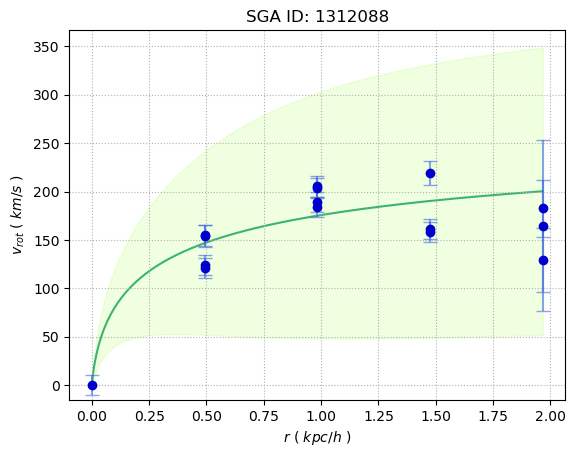

In [169]:
for i in np.unique(loa_rotvel['SGA_ID'])[:1]:

    sga_id = 1312088
    
    targ_id = loa_rotvel[loa_rotvel['SGA_ID'] == sga_id]

    # grab all fibers with velocity < 1000 km/s and passed VI
    valid_fibers = targ_id[(abs(targ_id['Velocity'])<1000) & (targ_id['bad_map']==0)]

    # make sure there are still 3 points to curve fit
    
    # grab radius
    r_kpc = valid_fibers['r_kpc']
    
    if (len(valid_fibers) < 3) or (len(np.unique(r_kpc.round(5))) < 3):
        continue

    # absolute velocities
    velocity = abs(valid_fibers['Velocity'])

    v_err = valid_fibers['V_err']
#----------------------------------------------------------------------------
#
#create a pseudo-center fiber if there isn't one to assist with curve fitting
#
#----------------------------------------------------------------------------

    if np.all(r_kpc) != 0:
        z_cen_err = valid_fibers['Z_center'][0]
        velocity = np.append(velocity,0)
        r_kpc = np.append(r_kpc,0)
        v_err = np.append(v_err,c*z_cen_err)

#-----------------------------------------
#
# initial guess and bounds for curve fit
#
#-----------------------------------------
    
    # index for max velocity for initial guess
    idx = np.argmax(velocity)

    # bounds for v max, r turn, and alpha
    bounds = [(0,1000),(0,np.max(r_kpc)),(0,100)]

    # initial guess for v max, r turn, and alpha
    initial_guess = [velocity[idx], r_kpc[idx], 1]

    # curve fit
    min_fxn = minimize(fun = chi2, 
                 x0 = initial_guess, 
                 args = (velocity, v_err, r_kpc), 
                 bounds = bounds, 
                 method = 'Powell')
    
    # vmax_fit, rturn_fit, alpha_fit
    min_fits = min_fxn.x
    
    # get reduced chi 2
    chi2_fit= min_fxn.fun
    data_pts = len(velocity)
    
    reduced_chi2 = chi2_reduced(chi2_fit, data_pts)

#-------------------------------
#
# uncertainty from curve fit
#
#-------------------------------
    
    hessian = ndt.Hessian(chi2)
    hess = hessian(min_fits,velocity, v_err, r_kpc)

    # get covariance matrix for errors
    # make empty matrix of nans to prevent from plotting
    try:
    #covariance matrix
        hess_inv = 2*np.linalg.inv(hess)
    # vmax_err, rturn_err, alpha_err
        fit_params_err = np.sqrt(np.diag(np.abs(hess_inv)))
    
    except LinAlgError:
        # Do an alternate to the above
        hess_inv = np.full((3,3),np.nan)
#----------------
#
# plot
#
#----------------
    fig = plt.figure()
    ax = fig.add_subplot()

    # curve fit --------
    r1 = np.linspace(0,np.max(r_kpc),500)

    v_r = v_rot(r1,min_fits[0],min_fits[1],min_fits[2])
    #-------------------

    # sample size
    size = 1000
    
    #plot uncertainty on the curve fit
    if ~np.isnan(hess_inv).any():
        samples=np.random.multivariate_normal(min_fits,hess_inv,size=size)

        # make sure all samples are positive
        good_samples = samples[(samples > 0).all(axis = 1)]
    
        # empty array for sample curve fit to go in
        v_sample = np.zeros((len(good_samples),500))
        
        # get curve fit for each sample distribution
        for i in range(len(good_samples)):
            indx = samples[i]
            v_x = v_rot(r1, indx[0], indx[1], indx[2])
            v_sample[i] = v_x
        
        #take standard deviation for all v_rot along each r
        std_dev = np.std(v_sample[~np.isnan(v_sample).any(axis=1)], axis = 0)

        # plot uncertainty
        ax.fill_between(r1, v_r - std_dev, v_r + std_dev, alpha = .12, color = 'chartreuse')
        
        # plot curve fit
        ax.plot(r1, v_r, color = 'mediumseagreen', zorder =1 )
        
    else:
        # plot curve fit
        ax.plot(r1, v_r, color = 'mediumseagreen', zorder = 1)
        
        # note the covariance matrix returned NAN
        ax.annotate('invalid hessian', xy = (10,10), xycoords = 'figure pixels')
    
    
    ax.grid(ls=':')

    # plot v vs r points and errorbars
    ax.errorbar(r_kpc, velocity, yerr = v_err, ls = 'none', ecolor = 'royalblue', capsize = 5, zorder=2, alpha = .6)
    ax.scatter(r_kpc, velocity, c = 'mediumblue', zorder = 3)
    
    ax.set_title('SGA ID: {}'.format(sga_id))
    ax.set_ylim(-15, None)
    ax.set(xlabel='$r$ $($ $kpc/h$ $)$', ylabel='$v_{rot}$ $($ $km/s$ $)$')
    
    # save everything to table or $PSCRATCH
    # fig.savefig('/pscratch/sd/d/dbustos/curve_fit/' + 'sga_{}_curve_fit.png'.format(sga_id), dpi=120)
    
    # fig.clear()
    # plt.close(fig)
    
    # np.save('/pscratch/sd/d/dbustos/hessian/' + str(sga_id) + '_hessian.npy', hess)
    
    # table_idx = (loa_rotvel['SGA_ID'] == sga_id) & ((abs(loa_rotvel['Velocity']) < 1000)) & (loa_rotvel['bad_map']==0)
    # loa_rotvel['chi2_reduced'][table_idx] = reduced_chi2

    # loa_rotvel['vmax_fit'][table_idx] = min_fxn[0]
    # loa_rotvel['rturn_fit'][table_idx] = min_fxn[1]
    # loa_rotvel['alpha_fit'][table_idx] = min_fxn[2]
    
    print('sga_id:',str(sga_id))
    print('minimize fits (v, r, α): ', min_fits)
    print('fit_params_err (v, r, α): ', fit_params_err)
    print('reduced chi2: ', reduced_chi2)

/tmp/ipykernel_1857253/2449382737.py:5: RuntimeWarning: divide by zero encountered in scalar divide
  return chi2/dof
/tmp/ipykernel_1857253/2399735231.py:103: RuntimeWarning: covariance is not symmetric positive-semidefinite.
  samples=np.random.multivariate_normal(min_fits,hess_inv,size=size)
/tmp/ipykernel_1857253/4036978402.py:2: RuntimeWarning: invalid value encountered in scalar power
  return (v_max * r)/((r_turn**a + r**a)**(1/a))
/tmp/ipykernel_1857253/4036978402.py:2: RuntimeWarning: divide by zero encountered in power
  return (v_max * r)/((r_turn**a + r**a)**(1/a))
/tmp/ipykernel_1857253/4036978402.py:2: RuntimeWarning: overflow encountered in power
  return (v_max * r)/((r_turn**a + r**a)**(1/a))
/tmp/ipykernel_1857253/4036978402.py:2: RuntimeWarning: overflow encountered in scalar power
  return (v_max * r)/((r_turn**a + r**a)**(1/a))
/tmp/ipykernel_1857253/4036978402.py:2: RuntimeWarning: divide by zero encountered in divide
  return (v_max * r)/((r_turn**a + r**a)**(1/a

sga_id: 17643
minimize fits (v, r, α):  [425.69780886   1.94611496   0.99998379]
fit_params_err (v, r, α):  [1.88626175e+06 2.48163682e+04 1.67622402e+02]
reduced chi2:  inf
        r_kpc         
----------------------
     1.946158338876917
2.0174710813790667e-12
                   0.0


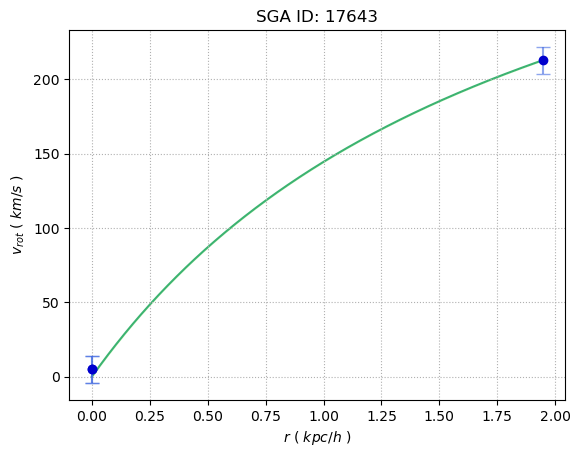

In [176]:
for i in np.unique(loa_rotvel['SGA_ID'])[:1]:

    sga_id = 17643
    
    targ_id = loa_rotvel[loa_rotvel['SGA_ID'] == sga_id]

    # grab all fibers with velocity < 1000 km/s and passed VI
    valid_fibers = targ_id[(abs(targ_id['Velocity'])<1000) & (targ_id['bad_map']==0)]

    # make sure there are still 3 points to curve fit
    if len(valid_fibers) < 3:
        continue

    # grab radius
    r_kpc = valid_fibers['r_kpc']
    
    # absolute velocities
    velocity = abs(valid_fibers['Velocity'])

    v_err = valid_fibers['V_err']
#----------------------------------------------------------------------------
#
#create a pseudo-center fiber if there isn't one to assist with curve fitting
#
#----------------------------------------------------------------------------

    if np.all(r_kpc) != 0:
        z_cen_err = valid_fibers['Z_center'][0]
        velocity = np.append(velocity,0)
        r_kpc = np.append(r_kpc,0)
        v_err = np.append(v_err,c*z_cen_err)

#-----------------------------------------
#
# initial guess and bounds for curve fit
#
#-----------------------------------------
    
    # index for max velocity for initial guess
    idx = np.argmax(velocity)

    # bounds for v max, r turn, and alpha
    bounds = [(0,1000),(0,np.max(r_kpc)),(0,100)]

    # initial guess for v max, r turn, and alpha
    initial_guess = [velocity[idx], r_kpc[idx], 1]

    # curve fit
    min_fxn = minimize(fun = chi2, 
                 x0 = initial_guess, 
                 args = (velocity, v_err, r_kpc), 
                 bounds = bounds, 
                 method = 'Powell')
    
    # vmax_fit, rturn_fit, alpha_fit
    min_fits = min_fxn.x
    
    # get reduced chi 2
    chi2_fit= min_fxn.fun
    data_pts = len(velocity)
    
    reduced_chi2 = chi2_reduced(chi2_fit, data_pts)

#-------------------------------
#
# uncertainty from curve fit
#
#-------------------------------
    
    hessian = ndt.Hessian(chi2)
    hess = hessian(min_fits,velocity, v_err, r_kpc)

    # get covariance matrix for errors
    # make empty matrix of nans to prevent from plotting
    try:
    #covariance matrix
        hess_inv = 2*np.linalg.inv(hess)
    # vmax_err, rturn_err, alpha_err
        fit_params_err = np.sqrt(np.diag(np.abs(hess_inv)))
    
    except LinAlgError:
        # Do an alternate to the above
        hess_inv = np.full((3,3),np.nan)
#----------------
#
# plot
#
#----------------
    fig = plt.figure()
    ax = fig.add_subplot()

    # curve fit --------
    r1 = np.linspace(0,np.max(r_kpc),500)

    v_r = v_rot(r1,min_fits[0],min_fits[1],min_fits[2])
    #-------------------

    # sample size
    size = 1000
    
    #plot uncertainty on the curve fit
    if ~np.isnan(hess_inv).any():
        samples=np.random.multivariate_normal(min_fits,hess_inv,size=size)

        # make sure all samples are positive
        good_samples = samples[(samples > 0).all(axis = 1)]
    
        # empty array for sample curve fit to go in
        v_sample = np.zeros((len(good_samples),500))
        
        # get curve fit for each sample distribution
        for i in range(len(good_samples)):
            indx = samples[i]
            v_x = v_rot(r1, indx[0], indx[1], indx[2])
            v_sample[i] = v_x
        
        #take standard deviation for all v_rot along each r
        std_dev = np.std(v_sample[~np.isnan(v_sample).any(axis=1)], axis = 0)

        # plot uncertainty
        ax.fill_between(r1, v_r - std_dev, v_r + std_dev, alpha = .12, color = 'chartreuse')
        
        # plot curve fit
        ax.plot(r1, v_r, color = 'mediumseagreen', zorder =1 )
        
    else:
        # plot curve fit
        ax.plot(r1, v_r, color = 'mediumseagreen', zorder = 1)
        
        # note the covariance matrix returned NAN
        ax.annotate('invalid hessian', xy = (10,10), xycoords = 'figure pixels')
    
    
    ax.grid(ls=':')

    # plot v vs r points and errorbars
    ax.errorbar(r_kpc, velocity, yerr = v_err, ls = 'none', ecolor = 'royalblue', capsize = 5, zorder=2, alpha = .6)
    ax.scatter(r_kpc, velocity, c = 'mediumblue', zorder = 3)
    
    ax.set_title('SGA ID: {}'.format(sga_id))
    #ax.set_ylim(-15, None)
    ax.set(xlabel='$r$ $($ $kpc/h$ $)$', ylabel='$v_{rot}$ $($ $km/s$ $)$')
    
    # save everything to table or $PSCRATCH
    # fig.savefig('/pscratch/sd/d/dbustos/curve_fit/' + 'sga_{}_curve_fit.png'.format(sga_id), dpi=120)
    
    # fig.clear()
    # plt.close(fig)
    
    # np.save('/pscratch/sd/d/dbustos/hessian/' + str(sga_id) + '_hessian.npy', hess)
    
    # table_idx = (loa_rotvel['SGA_ID'] == sga_id) & ((abs(loa_rotvel['Velocity']) < 1000)) & (loa_rotvel['bad_map']==0)
    # loa_rotvel['chi2_reduced'][table_idx] = reduced_chi2

    # loa_rotvel['vmax_fit'][table_idx] = min_fxn[0]
    # loa_rotvel['rturn_fit'][table_idx] = min_fxn[1]
    # loa_rotvel['alpha_fit'][table_idx] = min_fxn[2]
    
    # vmax, rturn, alpha
    print('sga_id:',str(sga_id))
    print('minimize fits (v, r, α): ', min_fits)
    print('fit_params_err (v, r, α): ', fit_params_err)
    print('reduced chi2: ', reduced_chi2)
    print(r_kpc)

## Test

minimize fits =  [2.89364905e+02 8.10901034e-02 5.00960444e-01]
fit_params_err =  [292.42876941   0.41796578   1.03545696]


/tmp/ipykernel_1160457/2607072621.py:61: RuntimeWarning: covariance is not symmetric positive-semidefinite.
  samples=np.random.multivariate_normal(min_fits,hess_inv,size=size)
/tmp/ipykernel_1160457/4036978402.py:2: RuntimeWarning: invalid value encountered in scalar power
  return (v_max * r)/((r_turn**a + r**a)**(1/a))
/tmp/ipykernel_1160457/4036978402.py:2: RuntimeWarning: divide by zero encountered in power
  return (v_max * r)/((r_turn**a + r**a)**(1/a))


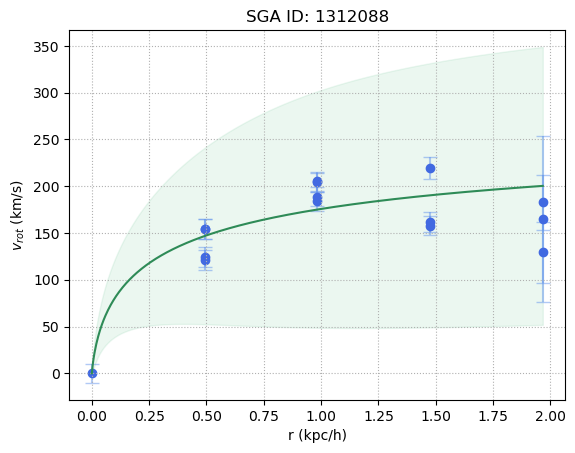

In [45]:
for i in np.unique(loa_rotvel['SGA_ID'])[:1]:

    sga_id = 1312088
    
    targ_id = loa_rotvel[loa_rotvel['SGA_ID'] == sga_id]

    valid_fibers = targ_id[(targ_id['Velocity']<1000) & (targ_id['bad_map']==0)]

    if len(valid_fibers) < 3:
        continue

    r_kpc = valid_fibers['r_kpc']
    
    #absolute velocities
    velocity = abs(valid_fibers['Velocity'])

    v_err = valid_fibers['V_err']

    #create a pseudo-center fiber if there isn't one to assist with curve fitting
    if np.all(r_kpc) != 0:
        z_cen_err = valid_fibers['Z_center'][0]
        velocity = np.append(velocity,0)
        r_kpc = np.append(r_kpc,0)
        v_err = np.append(v_err,c*z_cen_err)

    #index for max velocity for initial guess
    idx = np.argmax(velocity)

    #bounds for v max, r turn, and alpha
    bounds = [(0,1000),(0,np.max(r_kpc)),(0,100)]

    #initial guess for v max, r turn, and alpha
    initial_guess = [velocity[idx], r_kpc[idx], 1]

    #minimize fxn
    min_fxn = minimize(fun = chi2, 
                 x0 = initial_guess, 
                 args = (velocity, v_err, r_kpc), 
                 bounds = bounds, 
                 method = 'Powell')
    
    # vmax_fit, rturn_fit, alpha_fit
    min_fits = min_fxn.x

    hessian = ndt.Hessian(chi2)
    hess = hessian(min_fits,velocity, v_err, r_kpc)

    # try:
    #covariance matrix
    hess_inv = 2*np.linalg.inv(hess)
    # vmax_err, rturn_err, alpha_err
    fit_params_err = np.sqrt(np.diag(np.abs(hess_inv)))
    # except LinAlgError:
        # Do an alternate to the above

    print('minimize fits = ', min_fits)
    print('fit_params_err = ', fit_params_err)

    size = 1000

    samples=np.random.multivariate_normal(min_fits,hess_inv,size=size)
    
    good_samples = samples[(samples > 0).all(axis = 1)]
    
    r1 = np.linspace(0,np.max(r_kpc),500)

    v_r = v_rot(r1,min_fits[0],min_fits[1],min_fits[2])

    v_sample = np.zeros((len(good_samples),500))
    
    # get v_rot for each sample distribution
    for i in range(len(good_samples)):
        indx = samples[i]
        v_x = v_rot(r1, indx[0], indx[1], indx[2])
        v_sample[i] = v_x

    # print(v_sample)
    # print(~np.isnan(v_sample).any(axis=1))
    
    #take standard deviation for all v_rot along r
    std_dev = np.std(v_sample[~np.isnan(v_sample).any(axis=1)], axis = 0)
    
    fig = plt.figure()
    ax = fig.add_subplot()

    ax.grid(ls=':')

    ax.fill_between(r1, v_r - std_dev, v_r + std_dev, alpha = .1, color = 'mediumseagreen')
    
    ax.plot(r1, v_r, color = 'seagreen')
    ax.errorbar(r_kpc, velocity, yerr = v_err, ls = 'none', ecolor = 'cornflowerblue', capsize = 5, zorder=1,alpha = .5)
    ax.scatter(r_kpc, velocity, c = 'royalblue')
    
    ax.set_title('SGA ID: {}'.format(sga_id))
    ax.set(xlabel='r (kpc/h)', ylabel='$v_{rot}$ (km/s)')

 message: Optimization terminated successfully.
 success: True
  status: 0
     fun: 58.32465325486951
       x: [ 2.894e+02  8.109e-02  5.010e-01]
     nit: 10
   direc: [[-3.224e+01 -3.990e-01 -4.988e-02]
           [ 4.122e+00 -1.462e-03 -9.816e-04]
           [-7.626e+00 -2.108e-02 -1.410e-02]]
    nfev: 462
      V_err       
------------------
10.298161926674412
10.384004050235493
 10.43574827418646
 32.65766447223178
10.526319461583018
11.109785211141851
 10.39006842433978
10.458613207663717
 88.40743142872842
 10.26893004041665
10.537393553215532
29.341869682310378
10.421359304469132
12.124322447104483
10.770139193269992


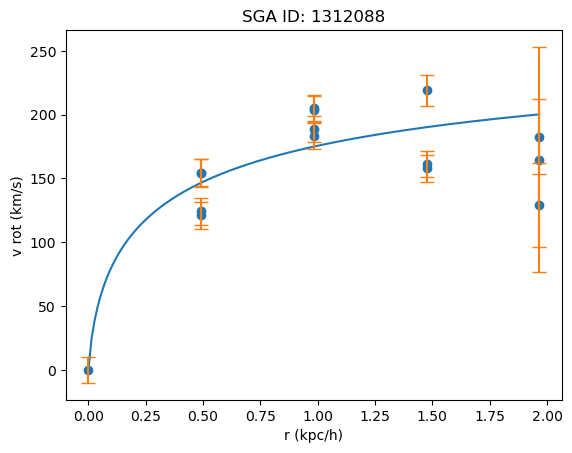

In [44]:
for i in np.unique(loa_rotvel['SGA_ID'])[:1]:

    sga_id = 1312088
    
    targ_id = loa_rotvel[loa_rotvel['SGA_ID'] == sga_id]

    valid_fibers = targ_id[(targ_id['Velocity']<1000) & (targ_id['bad_map']==0)]

    if len(valid_fibers) < 3:
        continue

    #r = valid_fibers['DIST_R26']
    r_kpc = valid_fibers['r_kpc']
    
    #absolute velocities
    velocity = abs(valid_fibers['Velocity'])

    v_err = valid_fibers['V_err']

    #index for max velocity for initial guess
    idx = np.argmax(velocity)

    #bounds for v max, r turn, and alpha
    bounds = [(0,1000),(0,np.max(r_kpc)),(0,100)]

    #initial guess for v max, r turn, and alpha
    initial_guess = [velocity[idx], r_kpc[idx], 1]

    #minimize fxn
    min_fxn = minimize(fun = chi2, 
                 x0 = initial_guess, 
                 args = (velocity, v_err, r_kpc), 
                 bounds = bounds, 
                 method = 'Powell')
    
    vmax_fit, rturn_fit, alpha_fit = min_fxn.x
    print(min_fxn)

    # print(vmax_fit,rturn_fit,alpha_fit)
    # print(v_rot(r_kpc,vmax_fit, rturn_fit, alpha_fit))

    r1 = np.linspace(0,np.max(r_kpc),len(r_kpc)*10)

    v_r = v_rot(r1,vmax_fit, rturn_fit, alpha_fit)

    fig = plt.figure()
    ax = fig.add_subplot()
    ax.scatter(r_kpc, velocity)
    ax.plot(r1,v_r)

    
    #ax.plot(r_kpc,v_rot(r_kpc,vmax_fit, rturn_fit, alpha_fit))
    ax.errorbar(r_kpc, velocity, yerr = v_err, ls='none', capsize=5)
    print(v_err)
    
    ax.set_title('SGA ID: {}'.format(sga_id))
    ax.set(xlabel='r (kpc/h)', ylabel='v rot (km/s)')